# Cache-Oblivious String Sorting

This notebook starts the implementation workflow for the cache-oblivious algorithms from the report. It sets up the environment, imports the reusable Python modules, defines a first batch of datasets, and runs basic correctness checks.

## 1. Set Up Project Environment

In [1]:
from pathlib import Path
import sys
import platform

PROJECT_ROOT = Path.cwd().resolve()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "Algorithms").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(platform.python_version())
print(PROJECT_ROOT)

3.12.11
/root/IAE/AlgoEngineering


## 2. Import Dependencies

In [8]:
from dataclasses import asdict, dataclass
from typing import cast

from Algorithms import (
    benchmark_sort,
    benchmark_suite,
    external_signature_sort,
    generate_dataset,
    generate_prefix_heavy_dataset,
    lazy_funnelsort,
    multikey_quicksort,
    python_sort,
    summarize_benchmarks,
)


## 3. Define Core Configuration

In [3]:
CACHE_OBLIVIOUS_ALGORITHMS = [
    ("python_sort", python_sort),
    ("multikey_quicksort", multikey_quicksort),
    ("external_signature_sort", external_signature_sort),
    ("lazy_funnelsort", lazy_funnelsort),
]

DATASET_LIBRARY = {
    "random": lambda count, seed: generate_dataset(count=count, seed=seed),
    "prefix_heavy": lambda count, seed: generate_prefix_heavy_dataset(count=count, seed=seed),
}


## 4. Implement Initial Data Structures

In [4]:
@dataclass(frozen=True)
class ExperimentCase:
    name: str
    dataset_name: str
    algorithm_name: str
    seed: int


EXPERIMENT_PLAN = [
    ExperimentCase(name="baseline-random", dataset_name="random", algorithm_name="python_sort", seed=0),
    ExperimentCase(name="prefix-heavy", dataset_name="prefix_heavy", algorithm_name="lazy_funnelsort", seed=1),
]


## 5. Add Basic Validation Checks

In [5]:
sample = generate_prefix_heavy_dataset(count=32, seed=42)
expected = sorted(sample)

benchmark_rows = []
for algorithm_name, algorithm in CACHE_OBLIVIOUS_ALGORITHMS:
    benchmark, output = benchmark_sort(algorithm_name, algorithm, sample)
    assert output == expected, f"{algorithm_name} produced an incorrect ordering"
    benchmark_rows.append(asdict(benchmark))

benchmark_rows

[{'algorithm': 'python_sort',
  'count': 32,
  'total_length': 399,
  'elapsed_seconds': 3.6870005715172738e-06,
  'sorted_correctly': True},
 {'algorithm': 'multikey_quicksort',
  'count': 32,
  'total_length': 399,
  'elapsed_seconds': 4.2429001041455194e-05,
  'sorted_correctly': True},
 {'algorithm': 'external_signature_sort',
  'count': 32,
  'total_length': 399,
  'elapsed_seconds': 1.3623000995721668e-05,
  'sorted_correctly': True},
 {'algorithm': 'lazy_funnelsort',
  'count': 32,
  'total_length': 399,
  'elapsed_seconds': 2.839499939000234e-05,
  'sorted_correctly': True}]

## 6. Run a Benchmark Sweep


In [6]:
benchmark_rows = benchmark_suite(
    CACHE_OBLIVIOUS_ALGORITHMS,
    DATASET_LIBRARY,
    sizes=(32, 64, 128),
    seeds=(0, 1, 2),
)

benchmark_rows[:5]


[{'dataset': 'random',
  'count': 32,
  'seed': 0,
  'algorithm': 'python_sort',
  'elapsed_seconds': 3.998000465799123e-06,
  'sorted_correctly': True,
  'total_length': 403},
 {'dataset': 'random',
  'count': 32,
  'seed': 0,
  'algorithm': 'multikey_quicksort',
  'elapsed_seconds': 2.538999979151413e-05,
  'sorted_correctly': True,
  'total_length': 403},
 {'dataset': 'random',
  'count': 32,
  'seed': 0,
  'algorithm': 'external_signature_sort',
  'elapsed_seconds': 1.4917000953573734e-05,
  'sorted_correctly': True,
  'total_length': 403},
 {'dataset': 'random',
  'count': 32,
  'seed': 0,
  'algorithm': 'lazy_funnelsort',
  'elapsed_seconds': 2.7992000468657352e-05,
  'sorted_correctly': True,
  'total_length': 403},
 {'dataset': 'random',
  'count': 32,
  'seed': 1,
  'algorithm': 'python_sort',
  'elapsed_seconds': 2.149001375073567e-06,
  'sorted_correctly': True,
  'total_length': 412}]

## 7. Summarize Results


In [9]:
benchmark_summary = summarize_benchmarks(benchmark_rows)
benchmark_summary = sorted(benchmark_summary, key=lambda row: cast(float, row["mean_elapsed_seconds"]))
benchmark_summary


[{'algorithm': 'python_sort',
  'runs': 18,
  'mean_elapsed_seconds': 6.668778041785117e-06,
  'min_elapsed_seconds': 1.9119997887173668e-06,
  'max_elapsed_seconds': 1.2346999938017689e-05,
  'all_sorted_correctly': True},
 {'algorithm': 'external_signature_sort',
  'runs': 18,
  'mean_elapsed_seconds': 3.6314944433494624e-05,
  'min_elapsed_seconds': 9.84799953585025e-06,
  'max_elapsed_seconds': 9.581800077285152e-05,
  'all_sorted_correctly': True},
 {'algorithm': 'lazy_funnelsort',
  'runs': 18,
  'mean_elapsed_seconds': 5.642849979873669e-05,
  'min_elapsed_seconds': 1.405100010742899e-05,
  'max_elapsed_seconds': 0.00018434199955663644,
  'all_sorted_correctly': True},
 {'algorithm': 'multikey_quicksort',
  'runs': 18,
  'mean_elapsed_seconds': 0.0002059036110545599,
  'min_elapsed_seconds': 2.238300112367142e-05,
  'max_elapsed_seconds': 0.002269643999170512,
  'all_sorted_correctly': True}]

## 8. Plot Comparisons


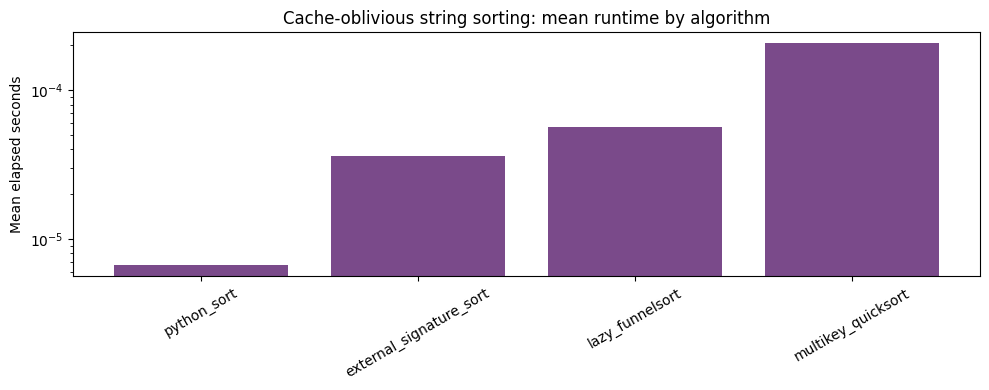

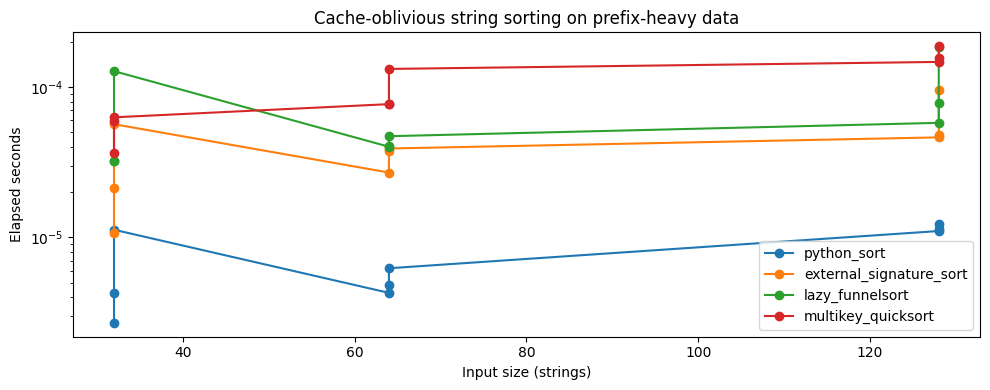

In [11]:
from collections import defaultdict

import matplotlib.pyplot as plt

summary_pairs = [
    (cast(str, row["algorithm"]), cast(float, row["mean_elapsed_seconds"]))
    for row in benchmark_summary
]
summary_pairs.sort(key=lambda pair: pair[1])
labels = [algorithm for algorithm, _ in summary_pairs]
means = [elapsed for _, elapsed in summary_pairs]

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(labels, means, color="#7a4a8a")
ax.set_title("Cache-oblivious string sorting: mean runtime by algorithm")
ax.set_ylabel("Mean elapsed seconds")
ax.set_yscale("log")
ax.tick_params(axis="x", rotation=30)
fig.tight_layout()
plt.show()

prefix_rows = [row for row in benchmark_rows if row["dataset"] == "prefix_heavy"]
trend_groups = defaultdict(list)
for row in prefix_rows:
    trend_groups[row["algorithm"]].append((row["count"], row["elapsed_seconds"]))

fig, ax = plt.subplots(figsize=(10, 4))
for algorithm_name in ["python_sort", "external_signature_sort", "lazy_funnelsort", "multikey_quicksort"]:
    points = sorted(trend_groups.get(algorithm_name, []))
    if not points:
        continue
    counts = [count for count, _ in points]
    elapsed = [value for _, value in points]
    ax.plot(counts, elapsed, marker="o", label=algorithm_name)

ax.set_title("Cache-oblivious string sorting on prefix-heavy data")
ax.set_xlabel("Input size (strings)")
ax.set_ylabel("Elapsed seconds")
ax.set_yscale("log")
ax.legend(loc="best")
fig.tight_layout()
plt.show()
